In [1]:
import sys

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts
import yaml

from pmt.io import *
from scipy.signal import find_peaks

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *
# from pmt.fit import *

from pmt.fit.core import *
from pmt.fit.poisson import fit_poisson_spe
from pmt.fit.bellamy import fit_bellamy_spe
from pmt.fit.wrappers import *


plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


# Poisson

### One distribuion


Loading cached dataframe from fit_data/260706/WA0089_850V_525MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-27.901120387017734), np.float64(155.14431114122283))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299915.0000 299714.4475     547.4744   [149957.5, 449872.5]   False
mu_pe                0.0600      0.0343       0.0004             [0.0, 5.0]   False
q0_mV_ns            -0.6000     -0.6951       0.0075           [-6.0, 10.0]   False
sigma0_mV_ns         3.9000      3.9805       0.0056            [0.0, 50.0]   False
q1_mV_ns            29.0000     29.3408       0.2285            [1.0, 40.0]   False
sigma1_mV_ns        12.0000     12.8951       0.1858            [0.2, 20.0]   False

 Gain is 3.66e+06 +-2.85e+04 for Q1 = 29.340819815294015


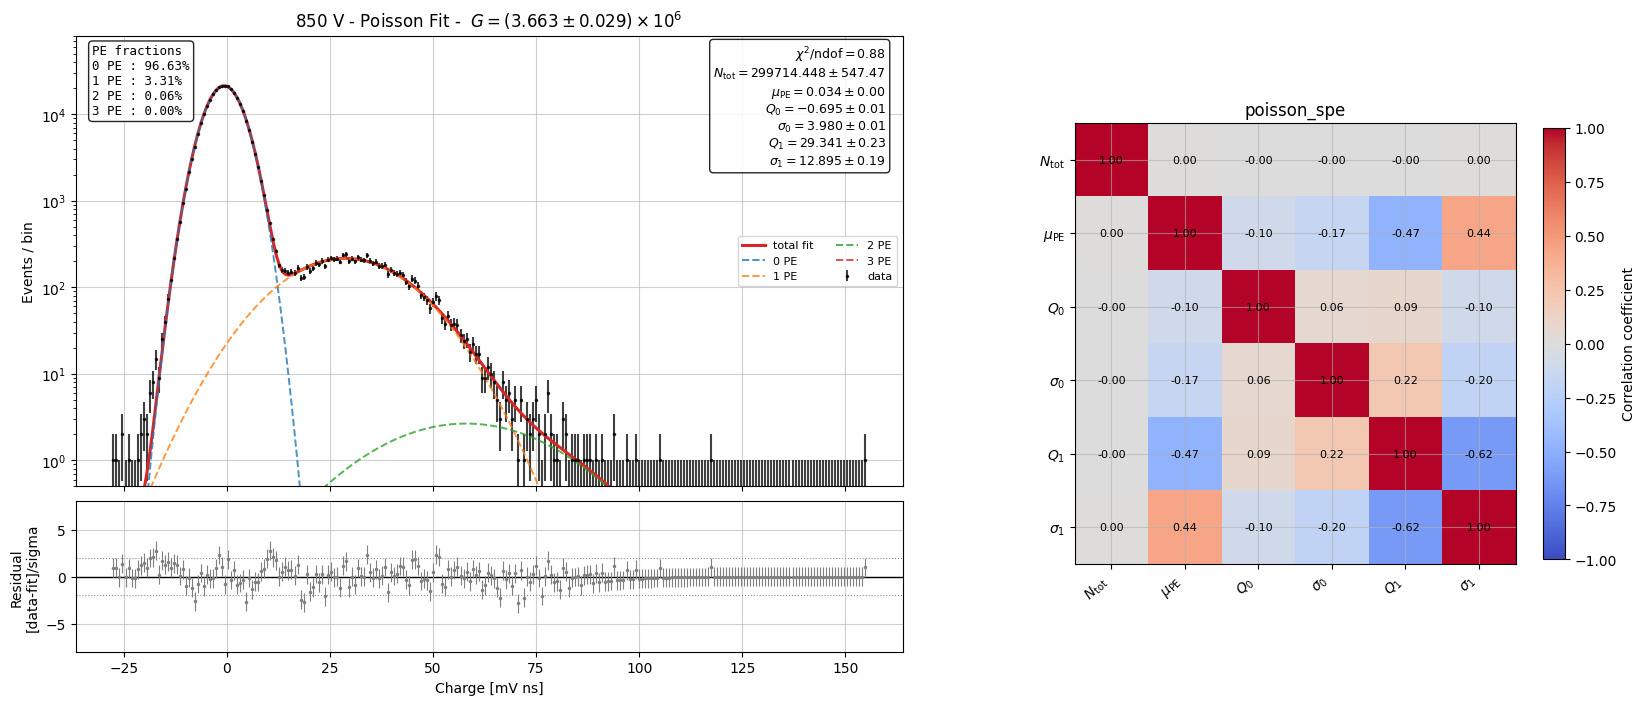

In [16]:
date, BW = "260706", "525"
# date, BW = "260709", "20"

fit_inputs = f"fit_data/{date}"
save_dir = f'plots/{date}/fit'
with open('config_files/fit_config.yaml') as f:
    cfg = yaml.safe_load(f)

inputV = 850
file_name = f"WA0089_{inputV}V_{BW}MHz_led100" 
fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, maxPE=3, nbins=250, fit_model="poisson", default_key="WA0089_20MHz_led100_defaults", save_results=False)



Loading cached dataframe from fit_data/260706/WA0089_750V_525MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-25.958094141911715), np.float64(46.969490944640704))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299816.0000 299625.7705     547.4006   [149908.0, 449724.0]   False
mu_pe                0.0600      0.0659       0.0023             [0.0, 5.0]   False
q0_mV_ns            -0.6000     -0.6403       0.0091           [-6.0, 10.0]   False
sigma0_mV_ns         3.9000      3.8861       0.0082            [0.0, 50.0]   False
q1_mV_ns            29.0000      6.0716       0.1870            [1.0, 40.0]   False
sigma1_mV_ns        12.0000      6.4241       0.0792            [0.2, 20.0]   False

 Gain is 7.58e+05 +-2.33e+04 for Q1 = 6.071559869225461

Loading cached dataframe from fit_data/260706/WA0089_775V_525MHz_led100_df.pkl
No fit r

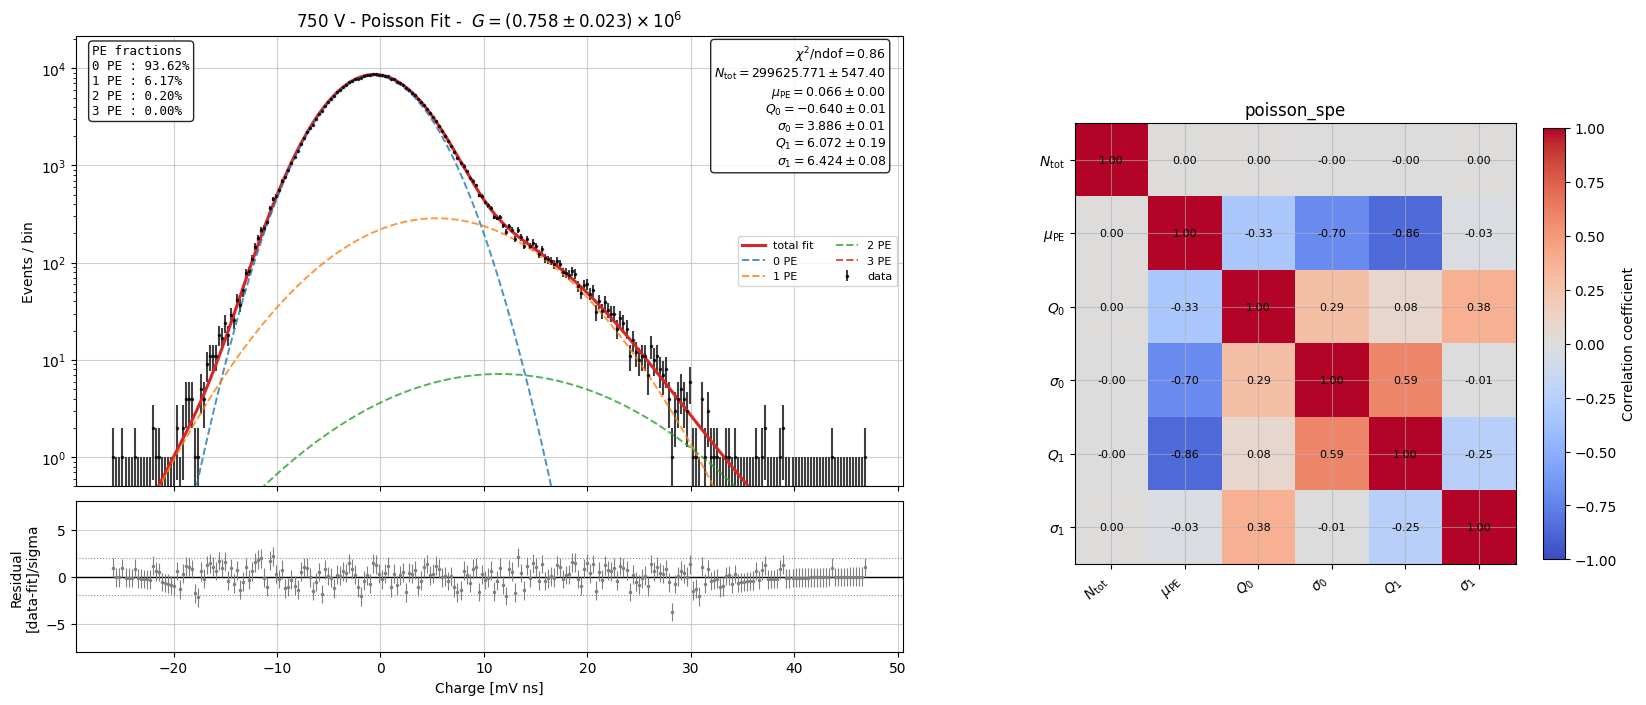

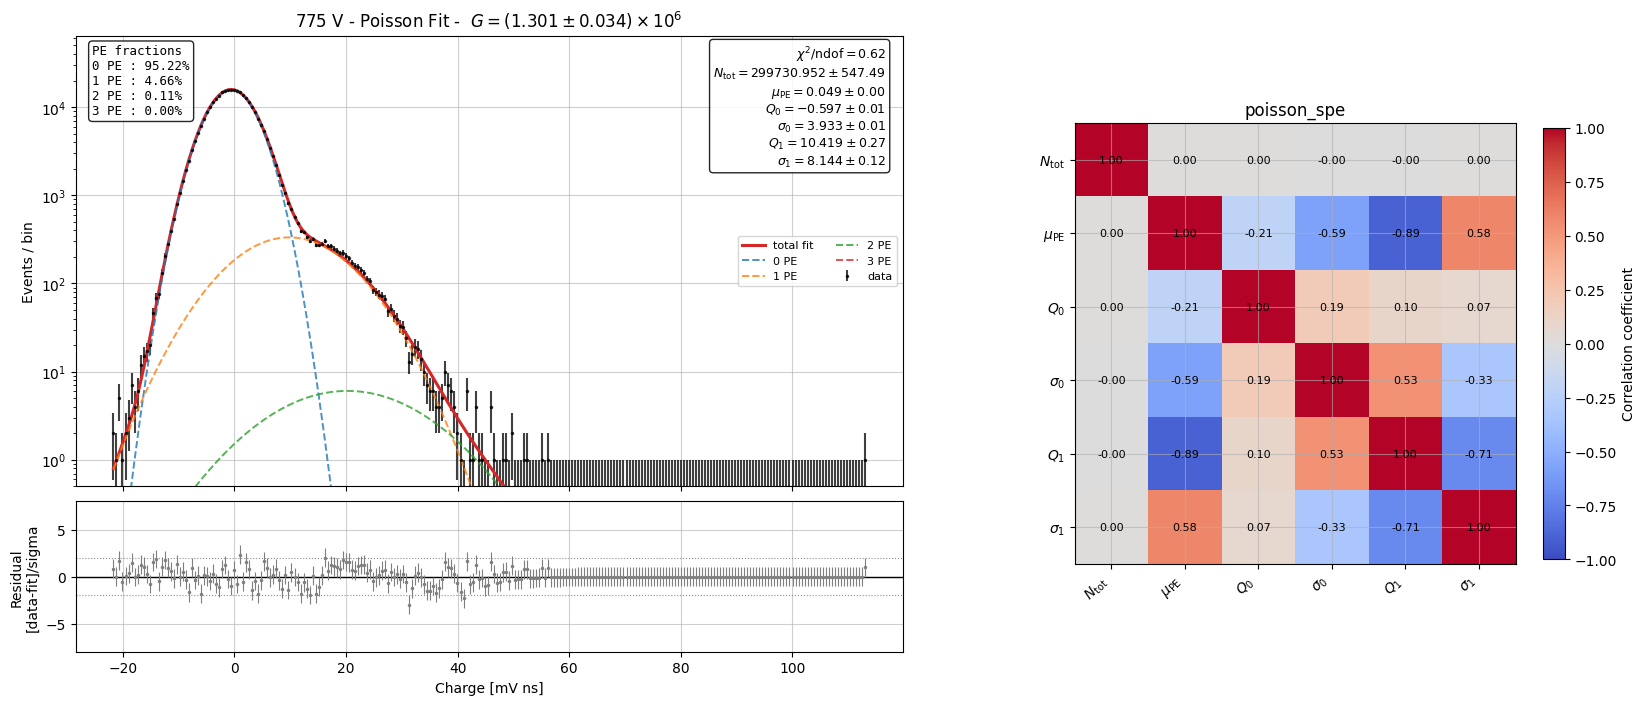

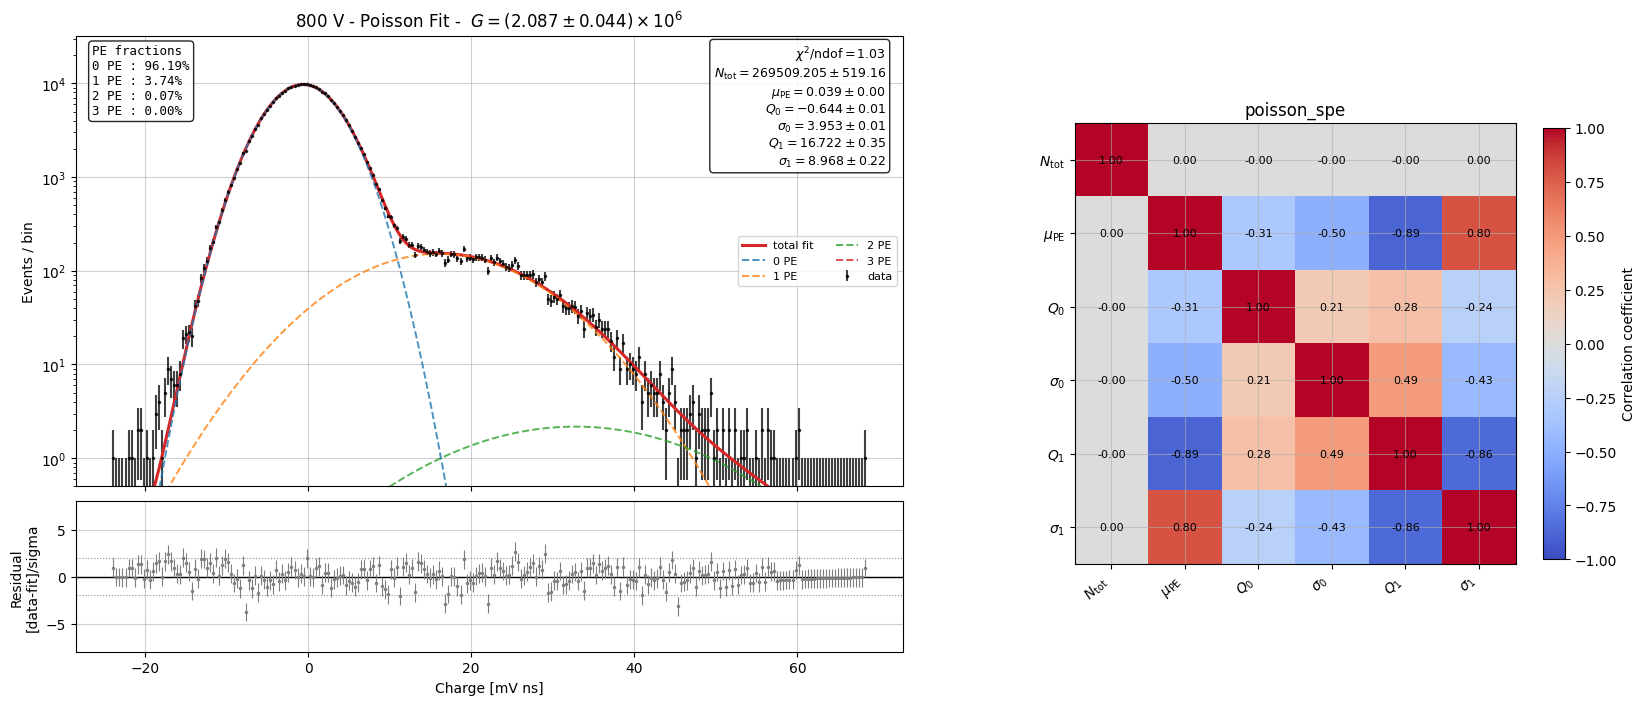

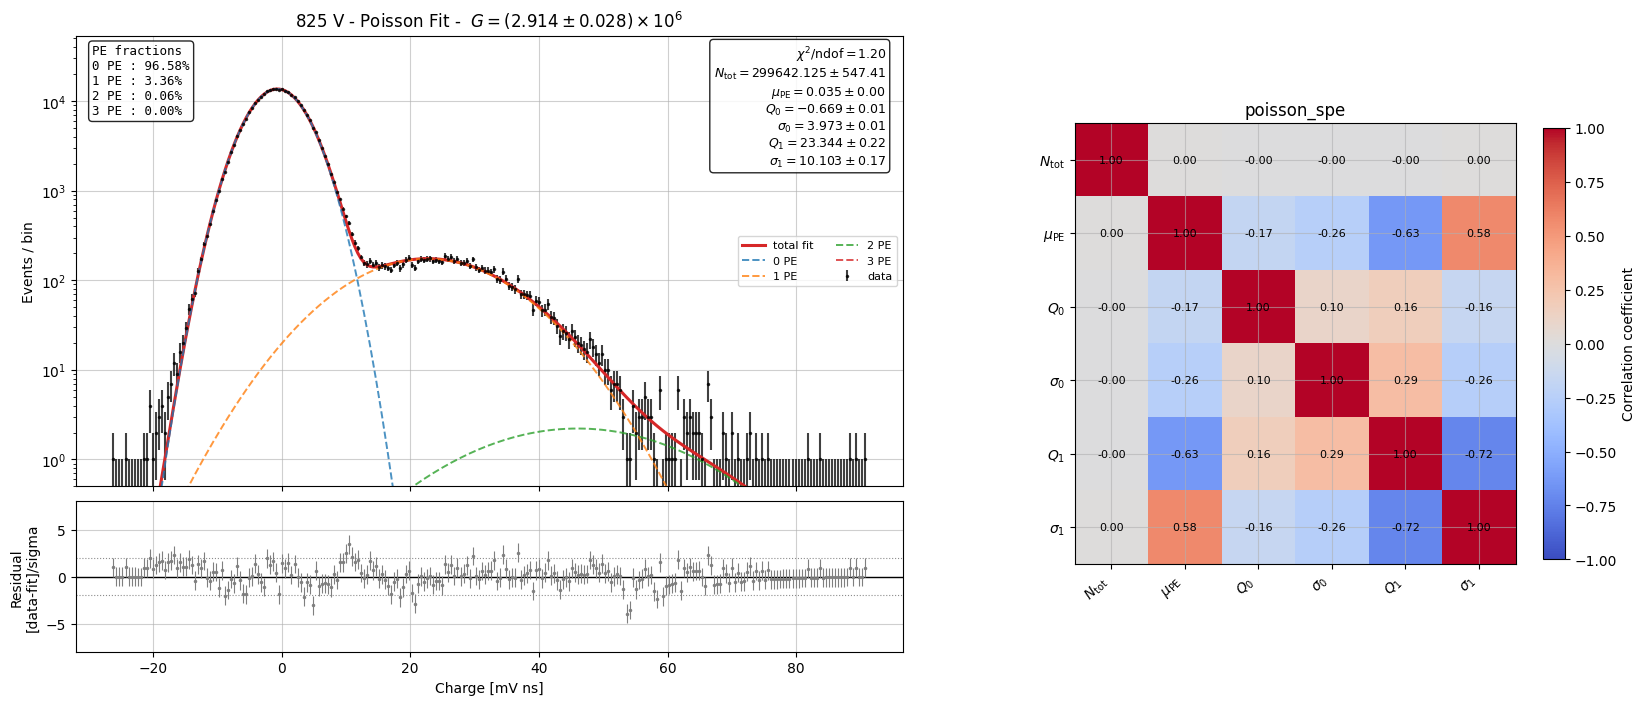

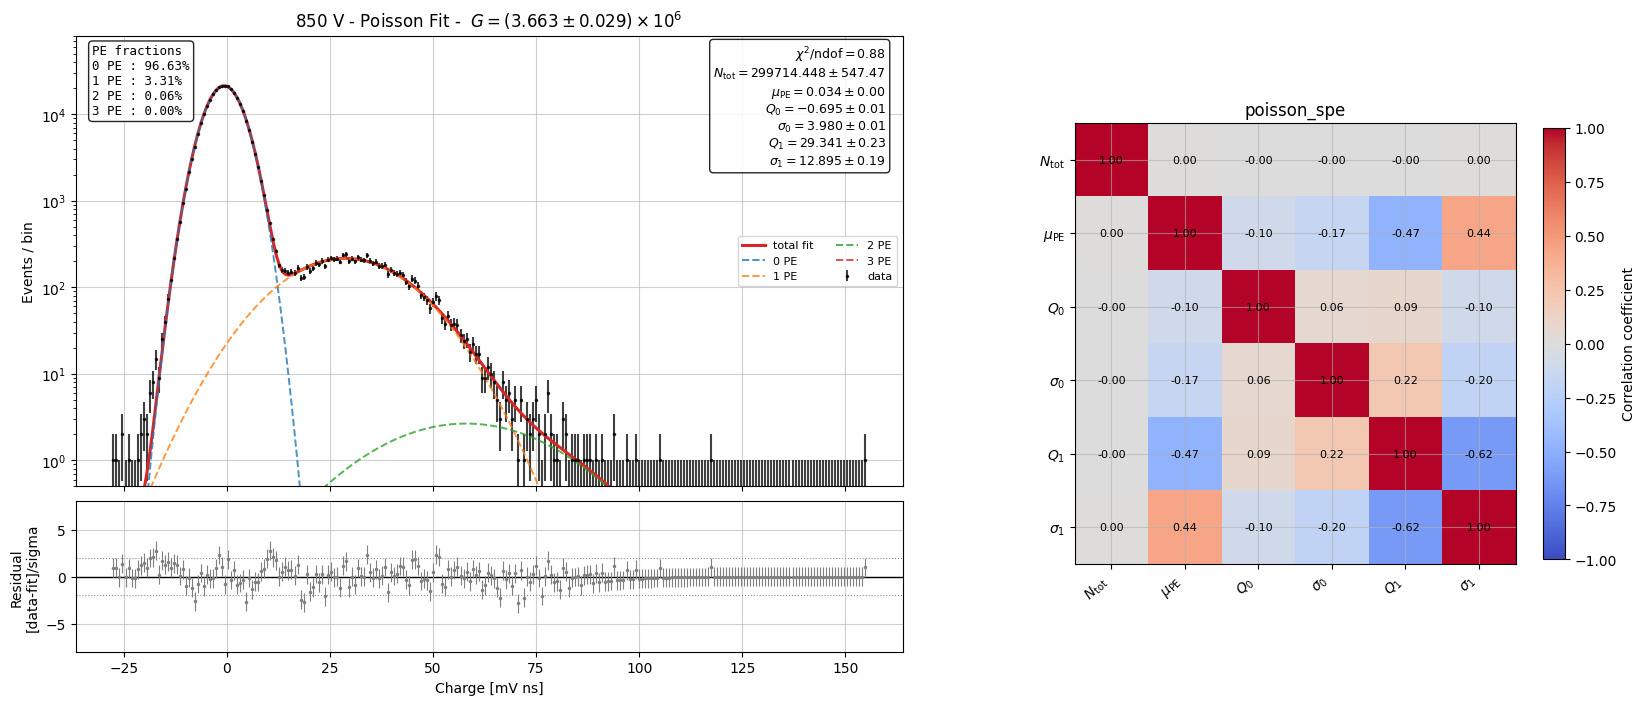

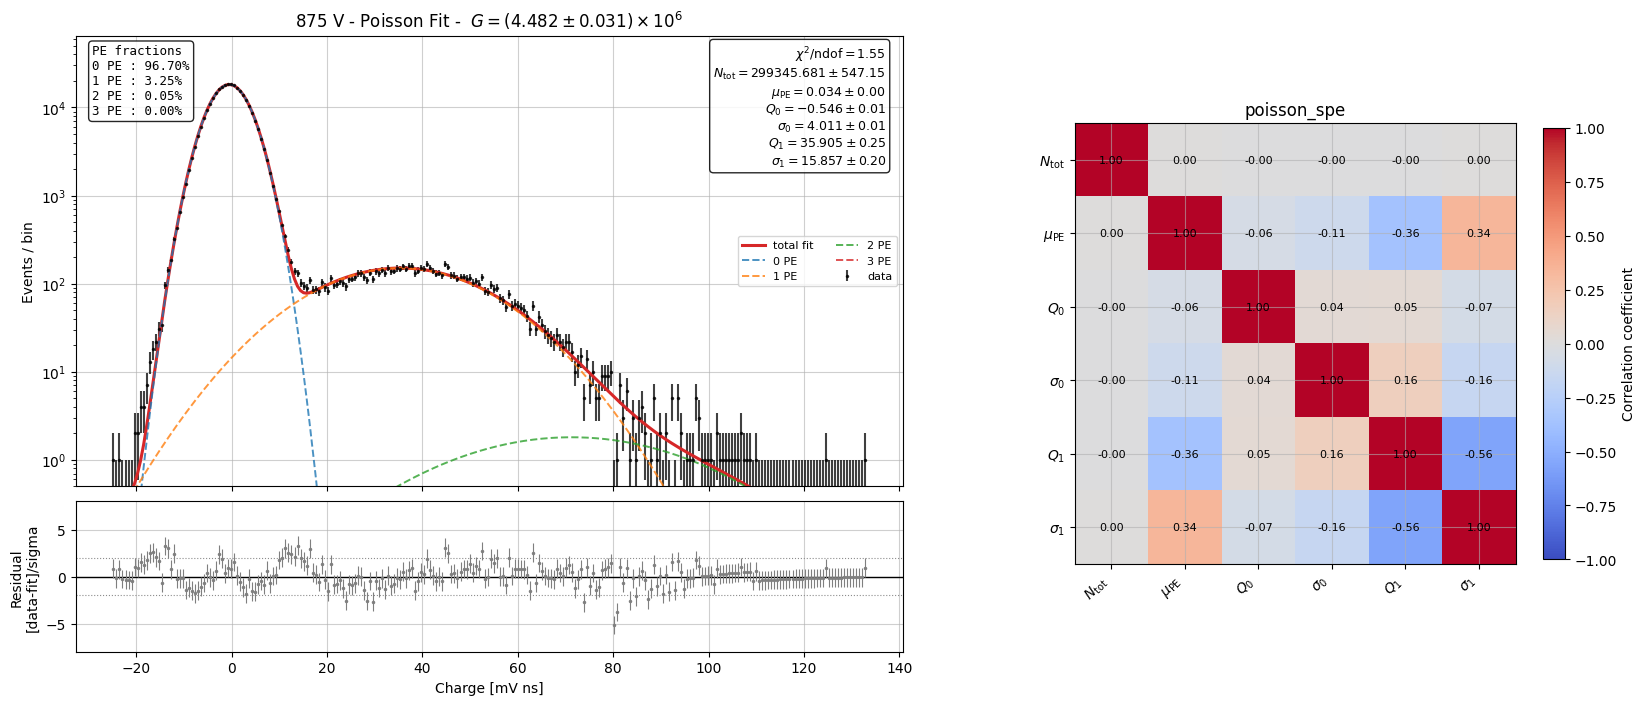

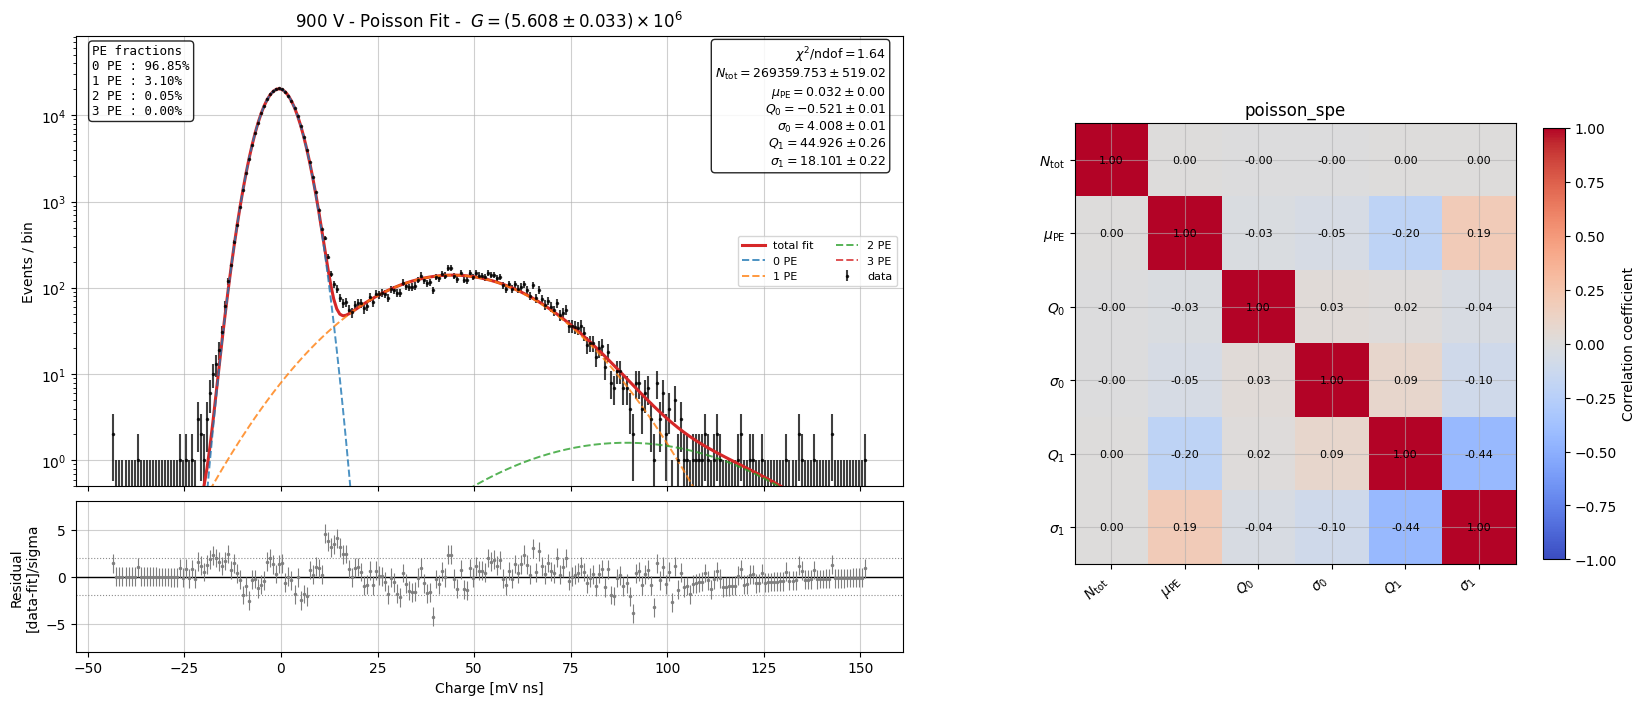

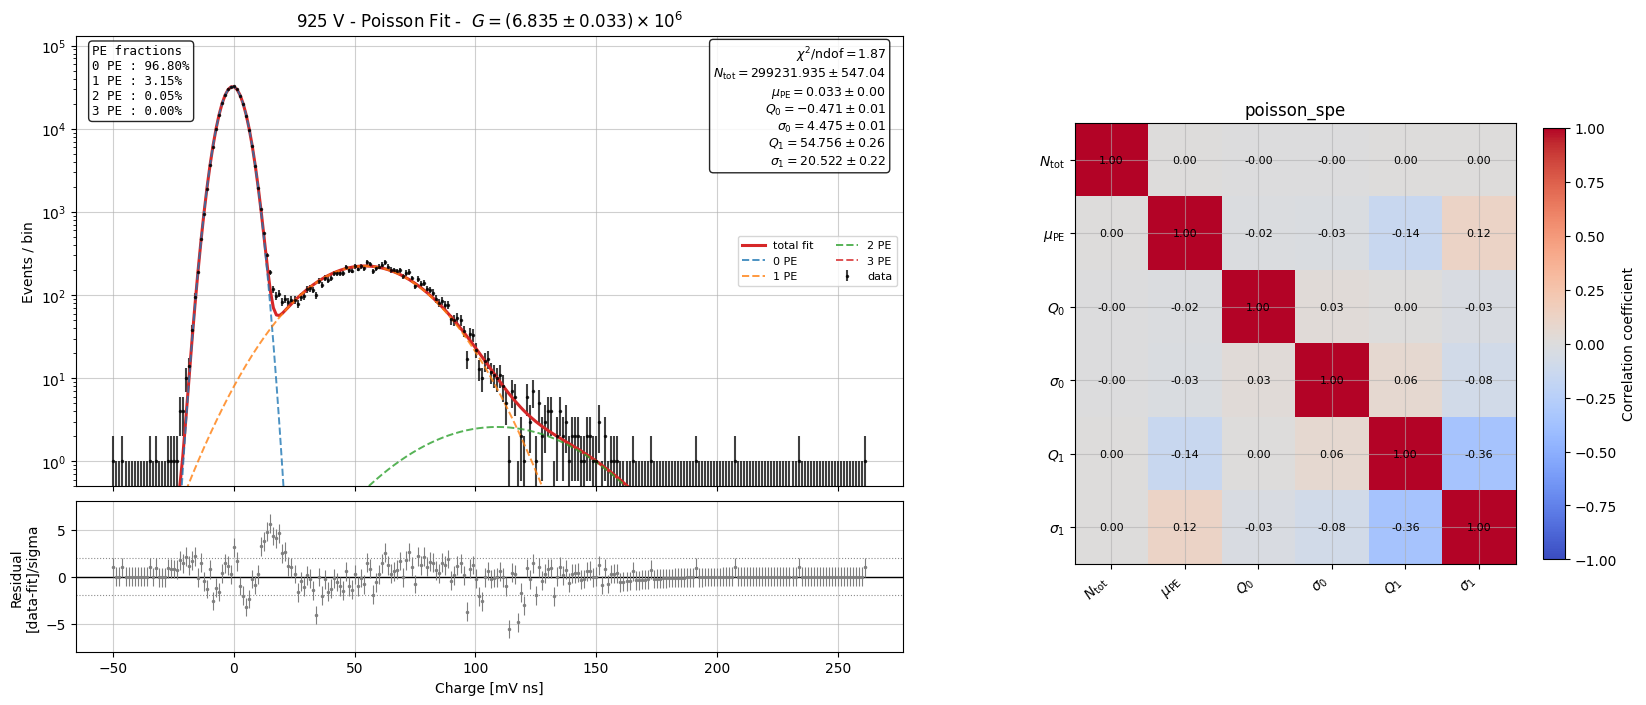

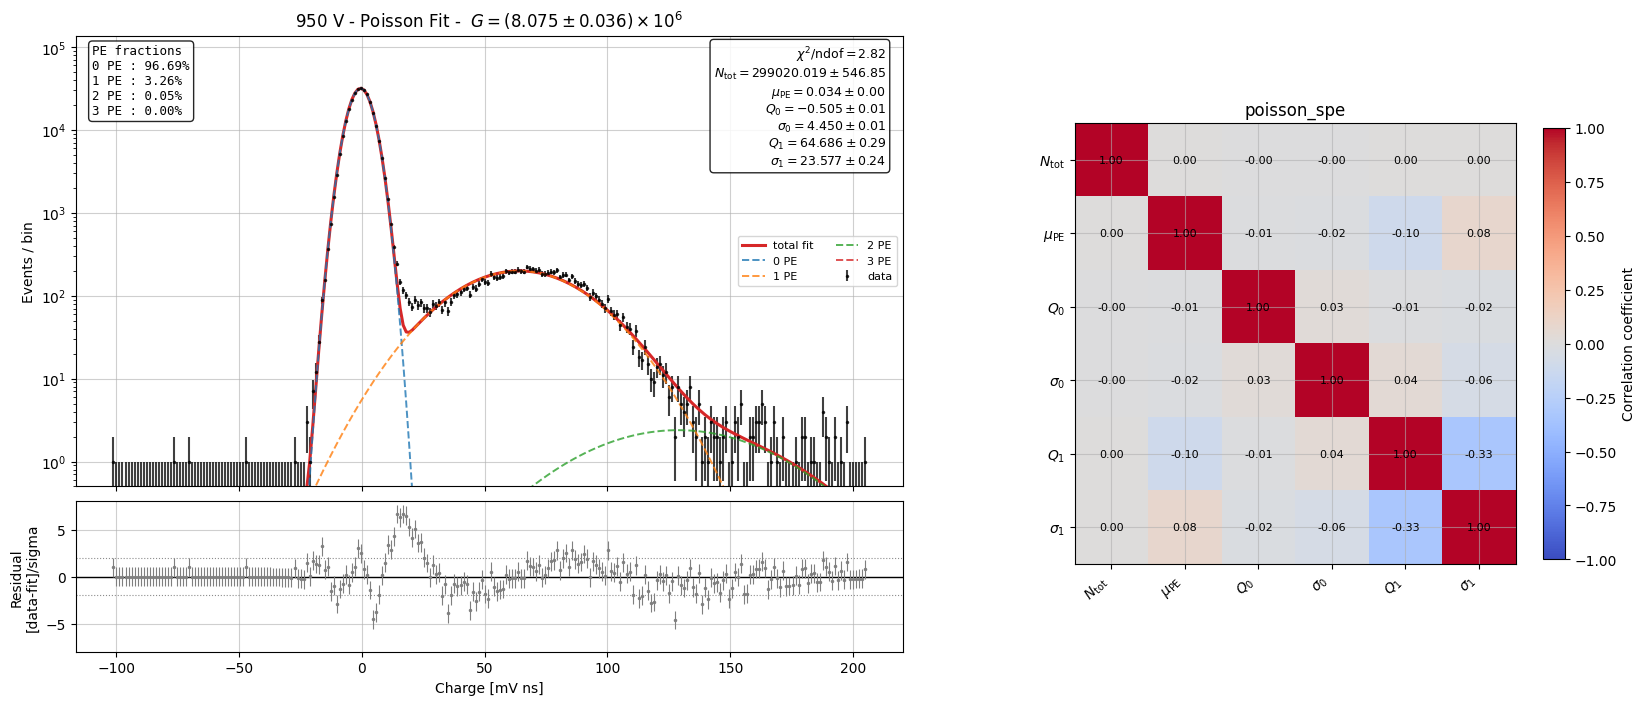

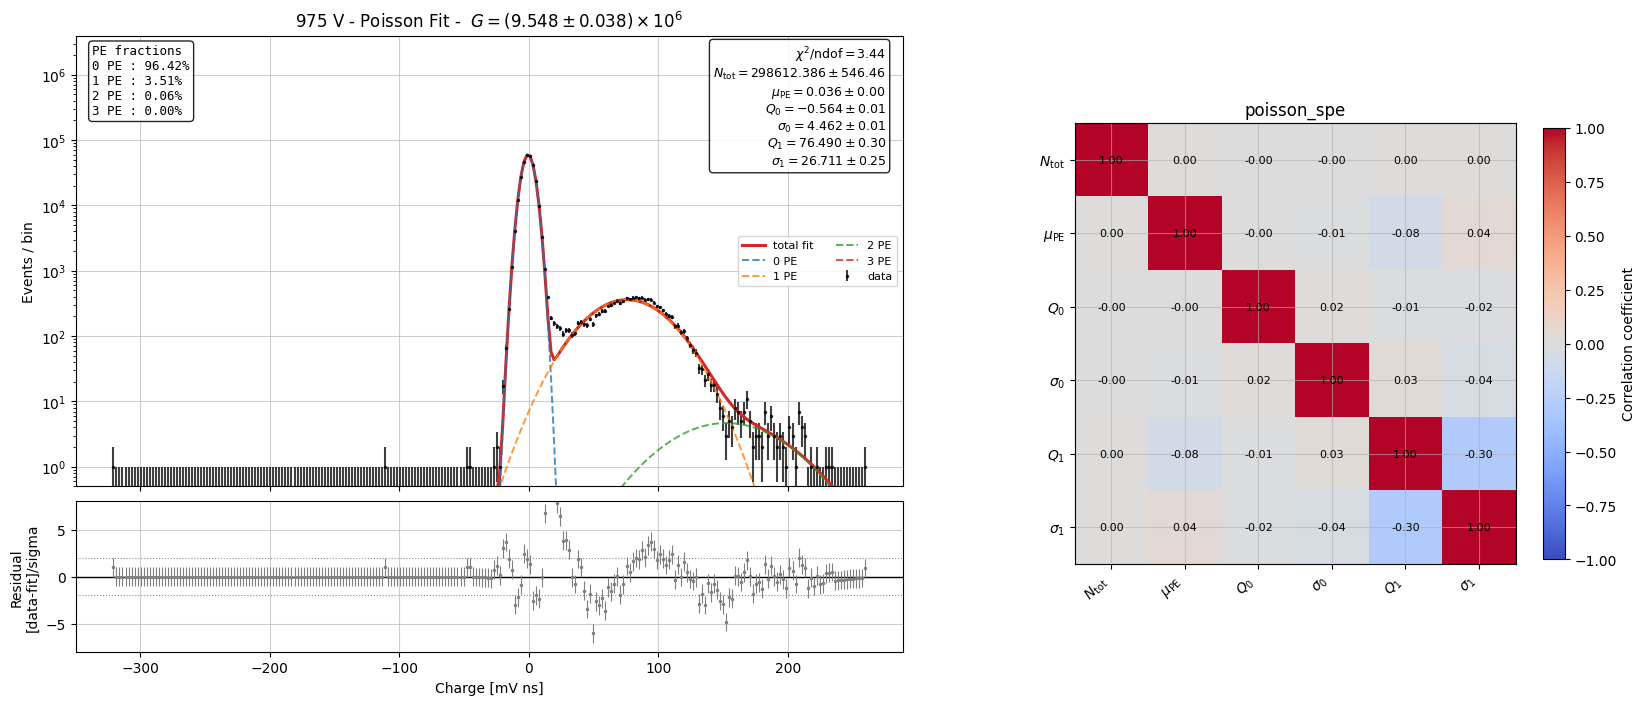

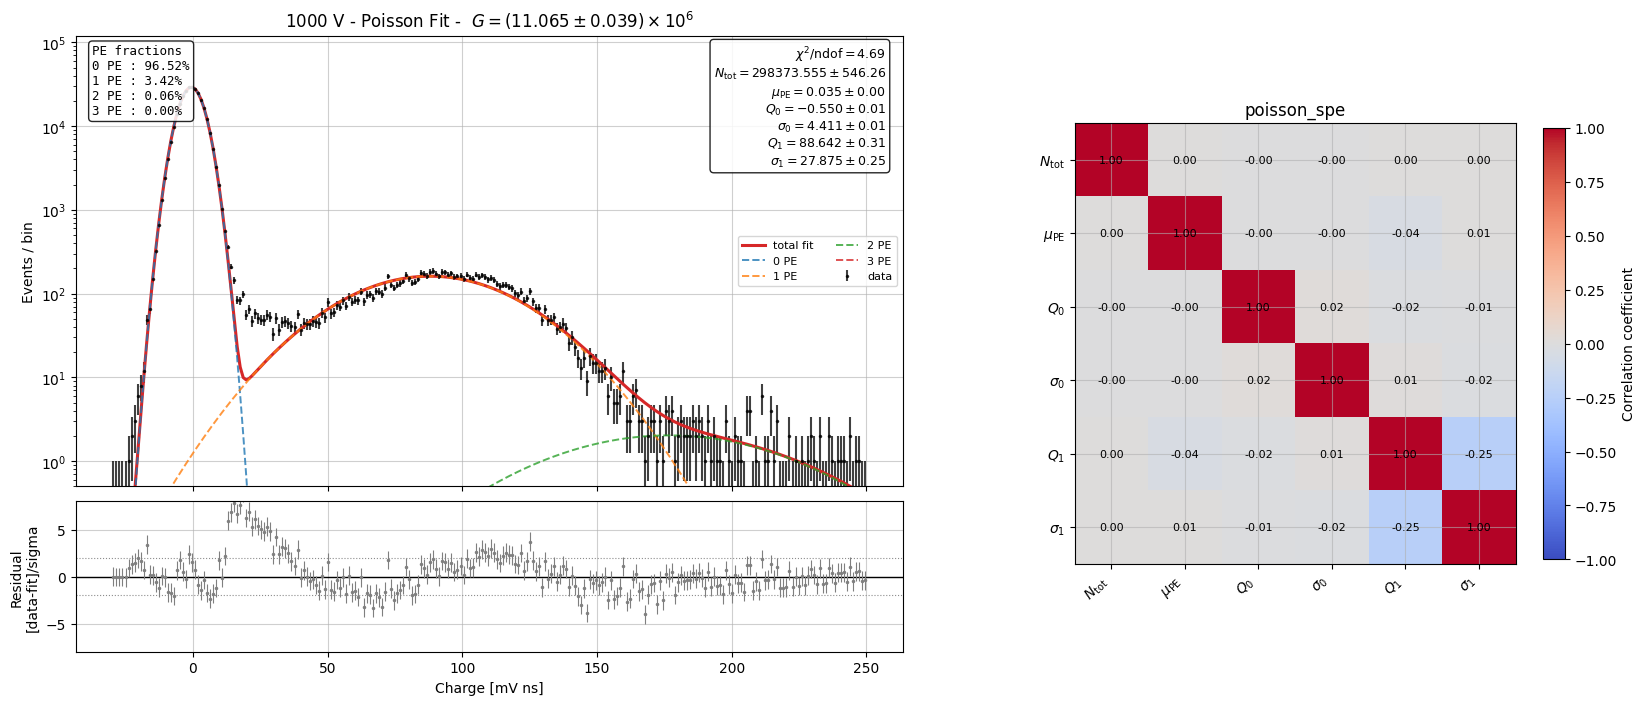

In [17]:
date, BW = "260706", "525"
# date, BW = "260709", "20"

fit_inputs = f"fit_data/{date}"
save_dir = f'plots/{date}/fit'
with open('config_files/fit_config.yaml') as f:
    cfg = yaml.safe_load(f)

for inputV in np.arange(750, 1001, 25):
    file_name = f"WA0089_{inputV}V_{BW}MHz_led100" 
    fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, fit_model="poisson", default_key="WA0089_20MHz_led100_defaults", lbl=None, save_results=False, initPars=None)




### Bellamy


Loading cached dataframe from fit_data/260709/WA0089_1000V_20MHz_led100_df.pkl
Fit range = [-60, 500]
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         258087.0000 256218.5322     506.2339   [129043.5, 387130.5]   False
mu_pe                0.0600      0.0285       0.0005             [0.0, 5.0]   False
q0_mV_ns            -1.3000      0.1607       0.0061            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      3.0067       0.0044            [0.0, 10.0]   False
q1_mV_ns           180.0000    195.1903       0.9646           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     51.9736       0.7460            [1.0, 80.0]   False
w                    0.0100      0.0095       0.0003             [0.0, 1.0]   False
alpha                0.1000      0.0205       0.0016            [0.0, 10.0]   False

 Gain is 2.44e+07 +-1.20e+05 for Q1 = 195.19028525403724


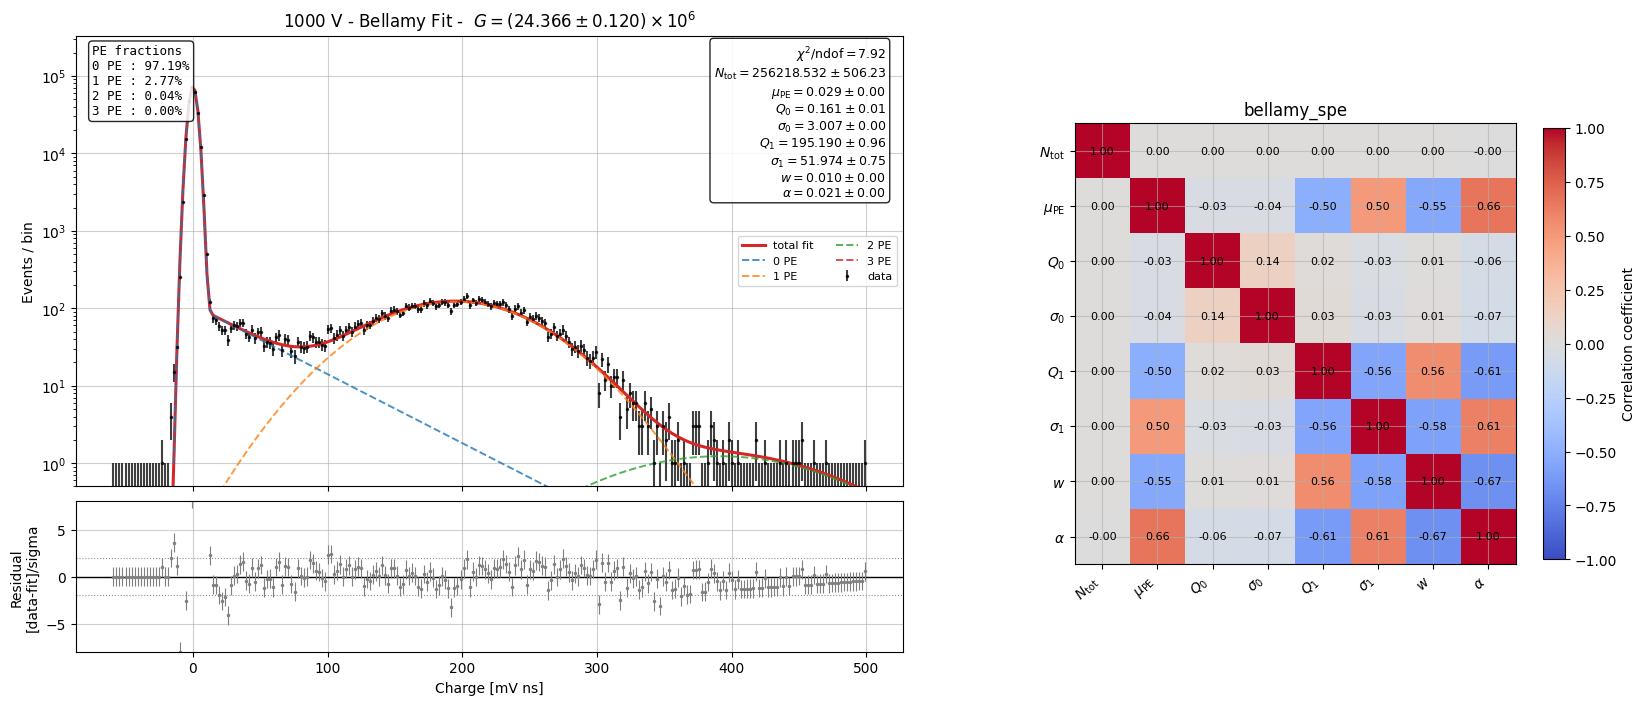

In [17]:
date = "260709"
fit_inputs = f"fit_data/{date}"
save_dir = f'plots/{date}/fit'
with open('config_files/fit_config.yaml') as f:
    cfg = yaml.safe_load(f)

# for inputV in np.arange(750, 1001, 25):
inputV = 1000
file_name = f"WA0089_{inputV}V_20MHz_led100" 

initPars = {
        'q0_mV_ns':     [ -1.3,  -5.0,   5.0,  False],
        'sigma0_mV_ns': [  2.6, '1e-4', 10.0,  False],
        'q1_mV_ns':     [180.0,  5.0,  200.0,  False],
        'sigma1_mV_ns': [12.0,  1.0,   80.0,   False],
        'mu_pe':        [ 0.06, 0.001,  5.0,   False],
        'w':            [ 0.01,  0.0,    1.0,   False],
        'alpha':        [ 0.1,  0.0,   10.0, False]
    }

fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults", lbl=None, save_results=False, initPars=initPars)


Loading cached dataframe from fit_data/260709/WA0089_750V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-20.50187611230649), np.float64(69.33517225878313))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299994.0000 299367.0168     547.1564   [149997.0, 449991.0]   False
mu_pe                0.0600      0.0183       0.0004             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -1.2658       0.0148            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.5712       0.0073            [0.0, 10.0]   False
q1_mV_ns            29.0000     22.8984       0.2608           [5.0, 200.0]   False
sigma1_mV_ns        12.0000      8.9816       0.1999            [1.0, 80.0]   False
w                    1.0000      1.0000       0.0000             [1.0, 1.0]    True
alpha                0.3000      0.6202       0.0059            

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: overflow encountered in exp
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: invalid value encountered in multiply
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)



Loading cached dataframe from fit_data/260709/WA0089_900V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-20.816147217527035), np.float64(303.2625172329135))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         270017.0000 268244.9691     518.9520   [135008.5, 405025.5]   False
mu_pe                0.0600      0.0272       0.0003             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -1.4553       0.0129            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.6192       0.0072            [0.0, 10.0]   False
q1_mV_ns            70.0000     84.8785       0.4803           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     32.9514       0.4301            [1.0, 80.0]   False
w                    1.0000      1.0000       0.0000             [1.0, 1.0]    True
alpha                0.3000      0.5793       0.0040           

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: overflow encountered in exp
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: invalid value encountered in multiply
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)



Loading cached dataframe from fit_data/260709/WA0089_925V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-22.767747848294675), np.float64(353.59823600994423))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         270009.0000 266662.2624     518.5026   [135004.5, 405013.5]   False
mu_pe                0.0600      0.0305       0.0003             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -0.3241       0.0237            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.7549       0.0090            [0.0, 10.0]   False
q1_mV_ns           100.0000    108.8617       0.5889           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     45.1133       0.4474            [1.0, 80.0]   False
w                    0.5000      0.2736       0.0135             [0.0, 1.0]   False
alpha                0.0900      0.4280       0.0064          

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: overflow encountered in exp
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: invalid value encountered in multiply
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)



Loading cached dataframe from fit_data/260709/WA0089_950V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-16.600970843806863), np.float64(402.6181262804894))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         270018.0000 244030.0643     518.4316   [135009.0, 405027.0]   False
mu_pe                0.0600      0.0291       0.0004             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -0.4315       0.0257            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.7282       0.0098            [0.0, 10.0]   False
q1_mV_ns           110.0000    127.7950       0.6530           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     43.1731       0.5561            [1.0, 80.0]   False
w                    0.5000      0.2770       0.0147             [0.0, 1.0]   False
alpha                0.0900      0.4346       0.0067           

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: overflow encountered in exp
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: invalid value encountered in multiply
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)



Loading cached dataframe from fit_data/260709/WA0089_975V_20MHz_led100_df.pkl
Fit range = [-50, 450]
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299944.0000 297708.8294     545.6514   [149972.0, 449916.0]   False
mu_pe                0.0600      0.0284       0.0004             [0.0, 5.0]   False
q0_mV_ns            -1.3000      0.1417       0.0057            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.9834       0.0040            [0.0, 10.0]   False
q1_mV_ns           150.0000    165.8530       0.7806           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     48.7704       0.5914            [1.0, 80.0]   False
w                    0.0100      0.0087       0.0002             [0.0, 1.0]   False
alpha                0.1000      0.0356       0.0022            [0.0, 10.0]   False

 Gain is 2.07e+07 +-9.74e+04 for Q1 = 165.85295255704156

Loa

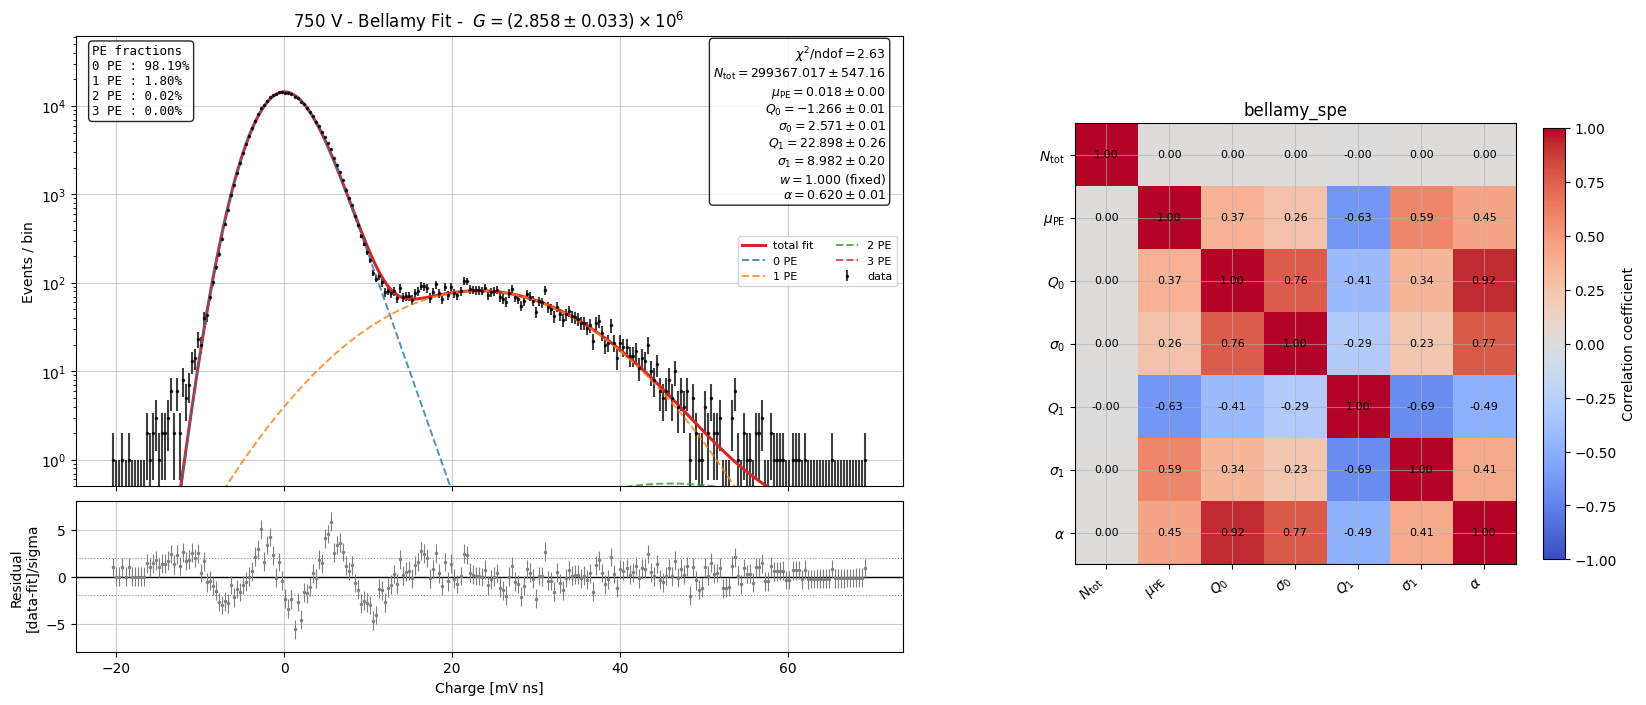

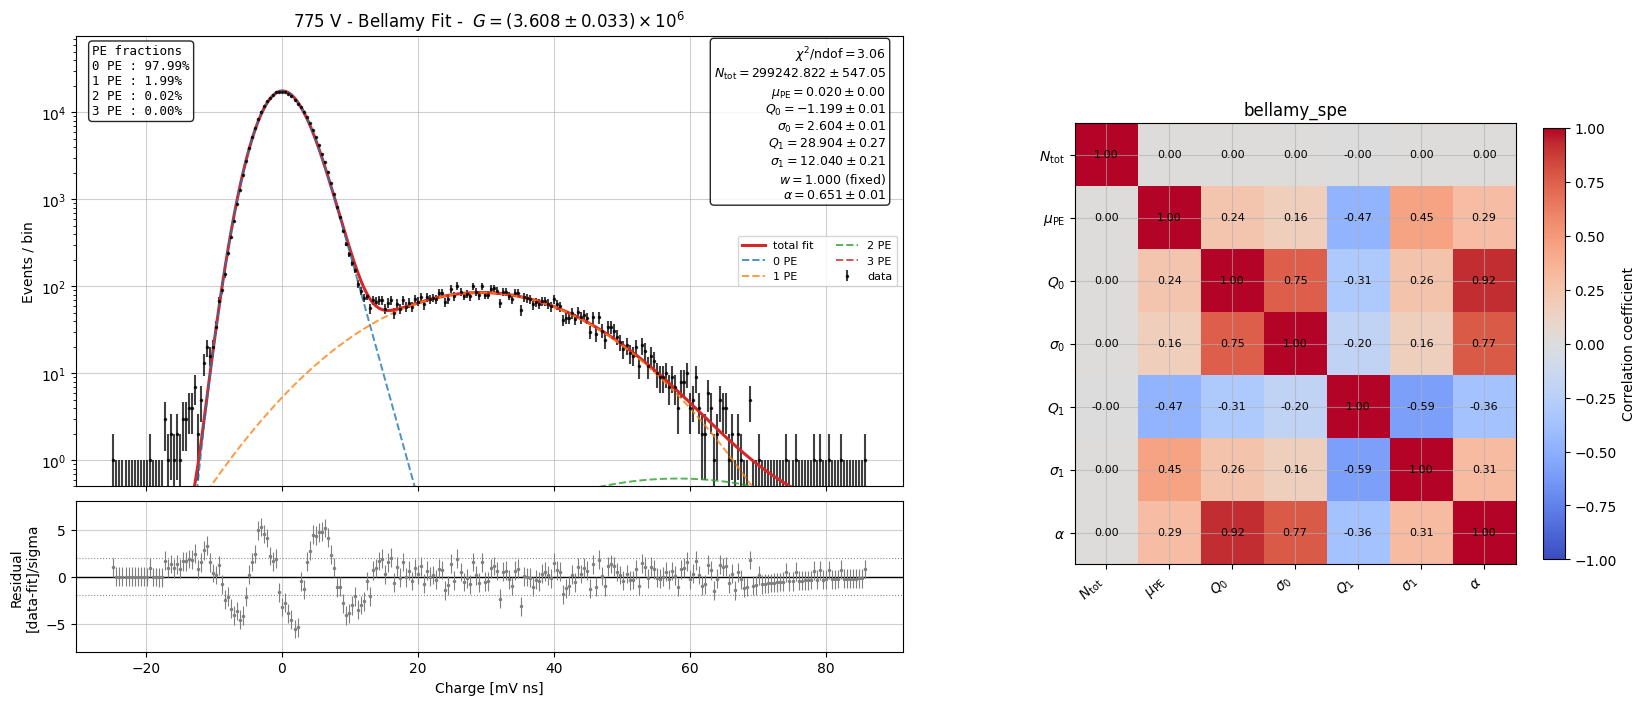

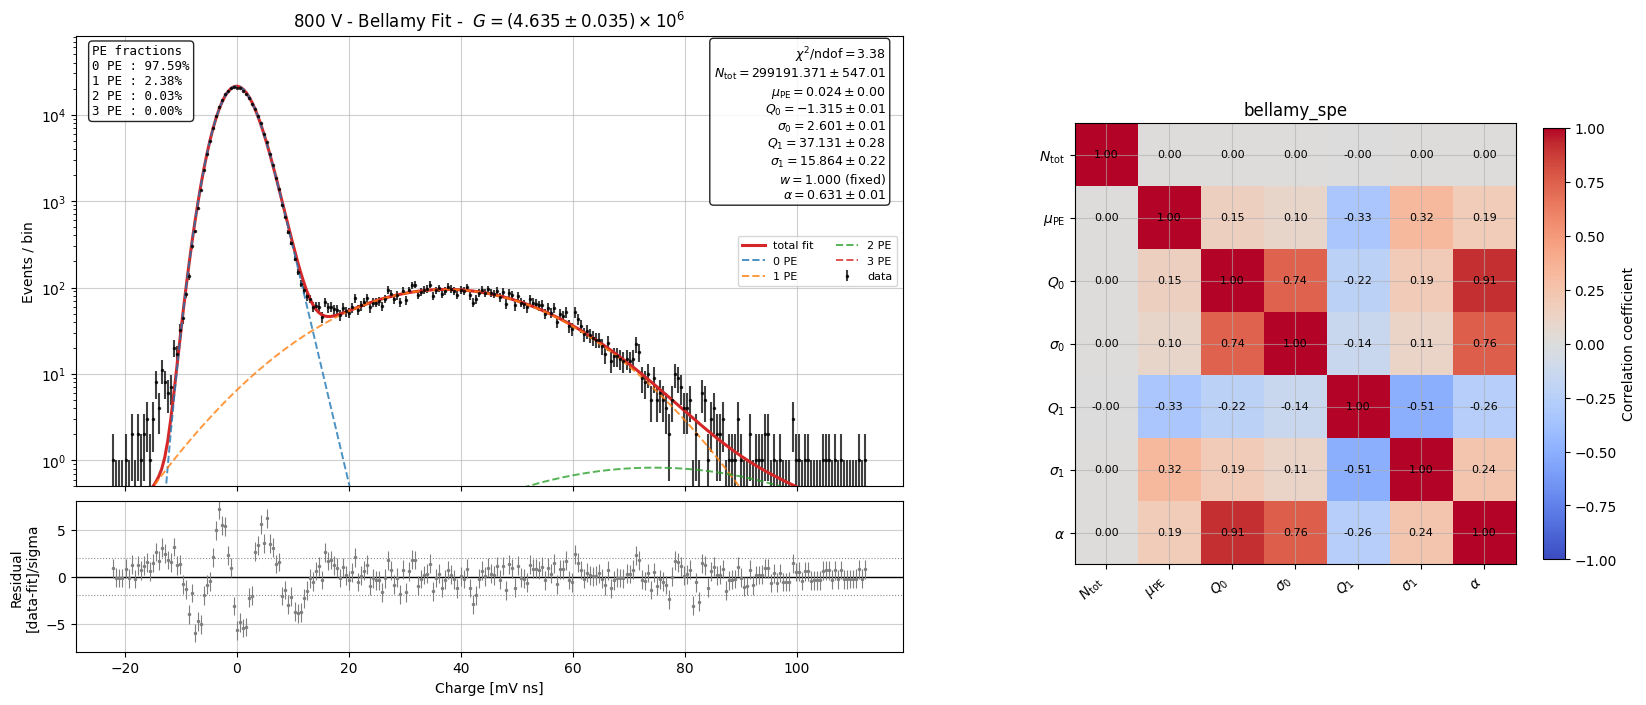

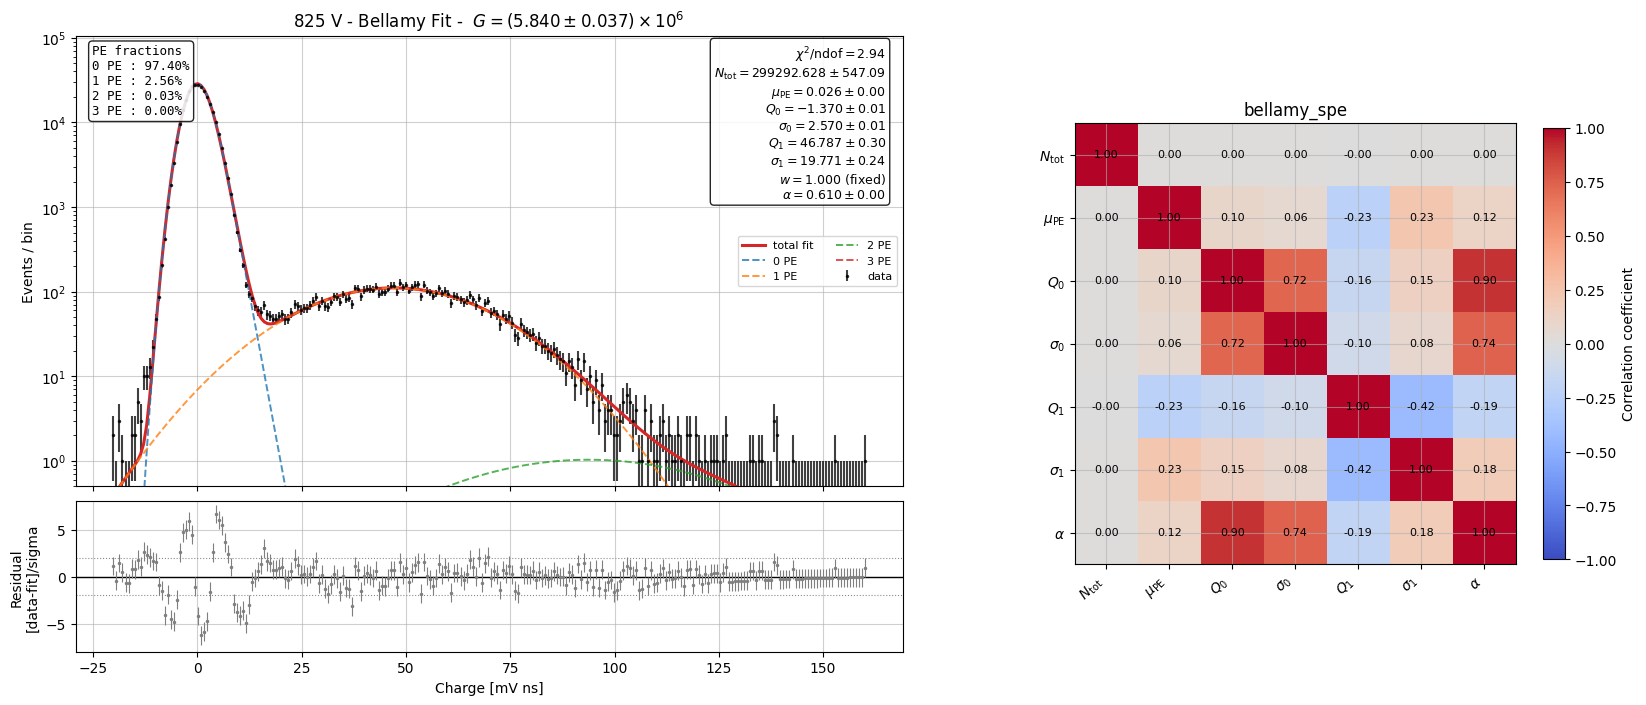

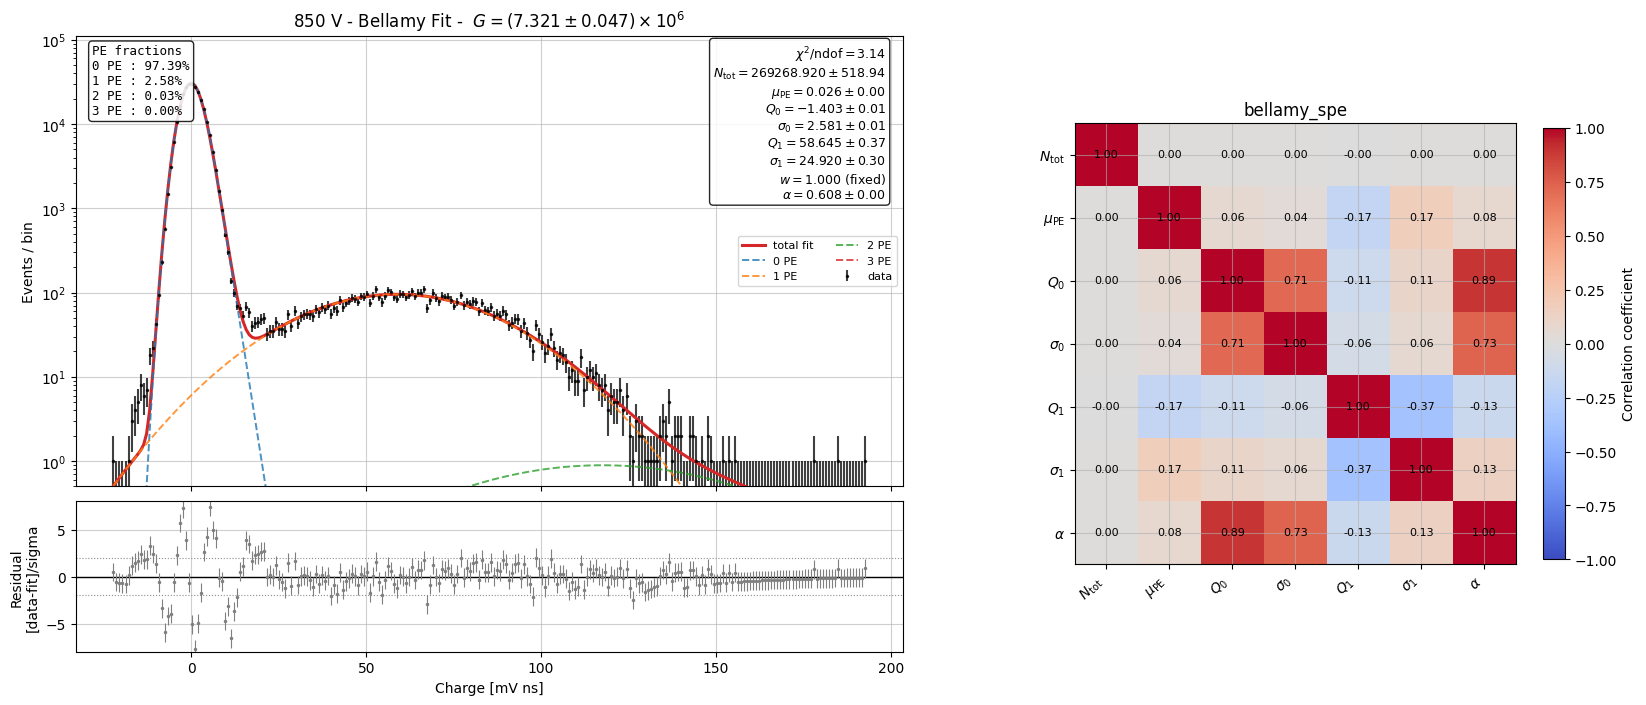

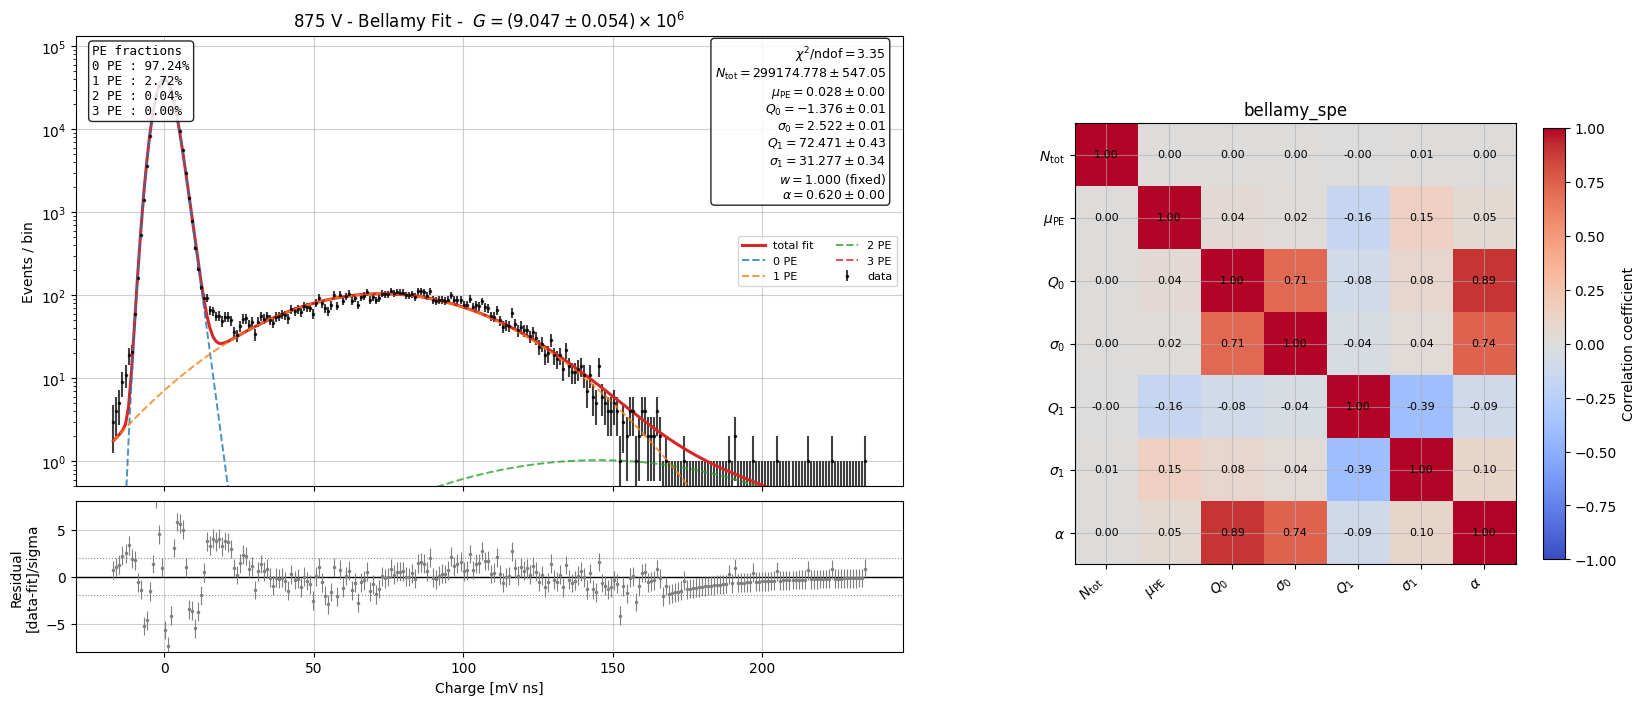

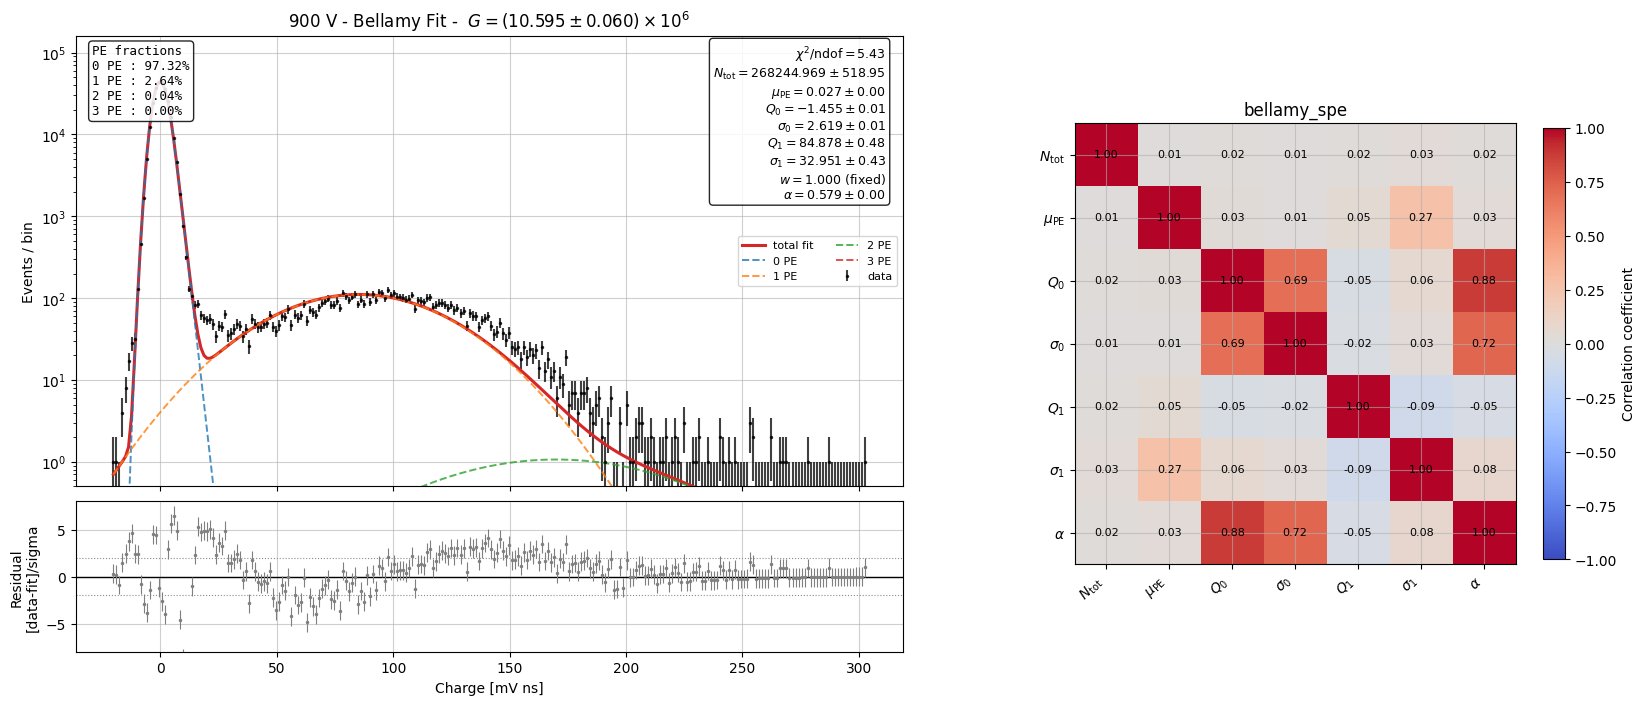

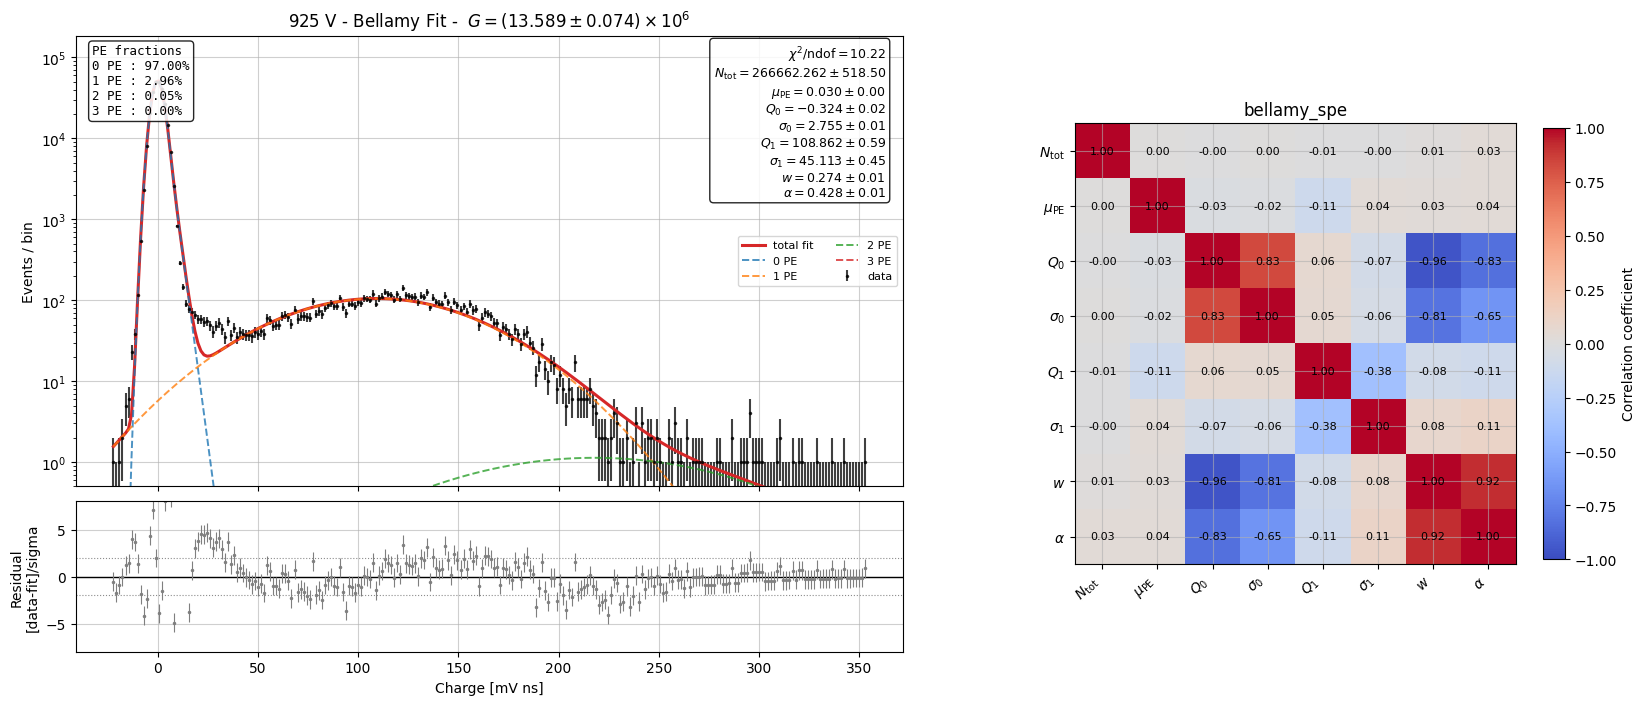

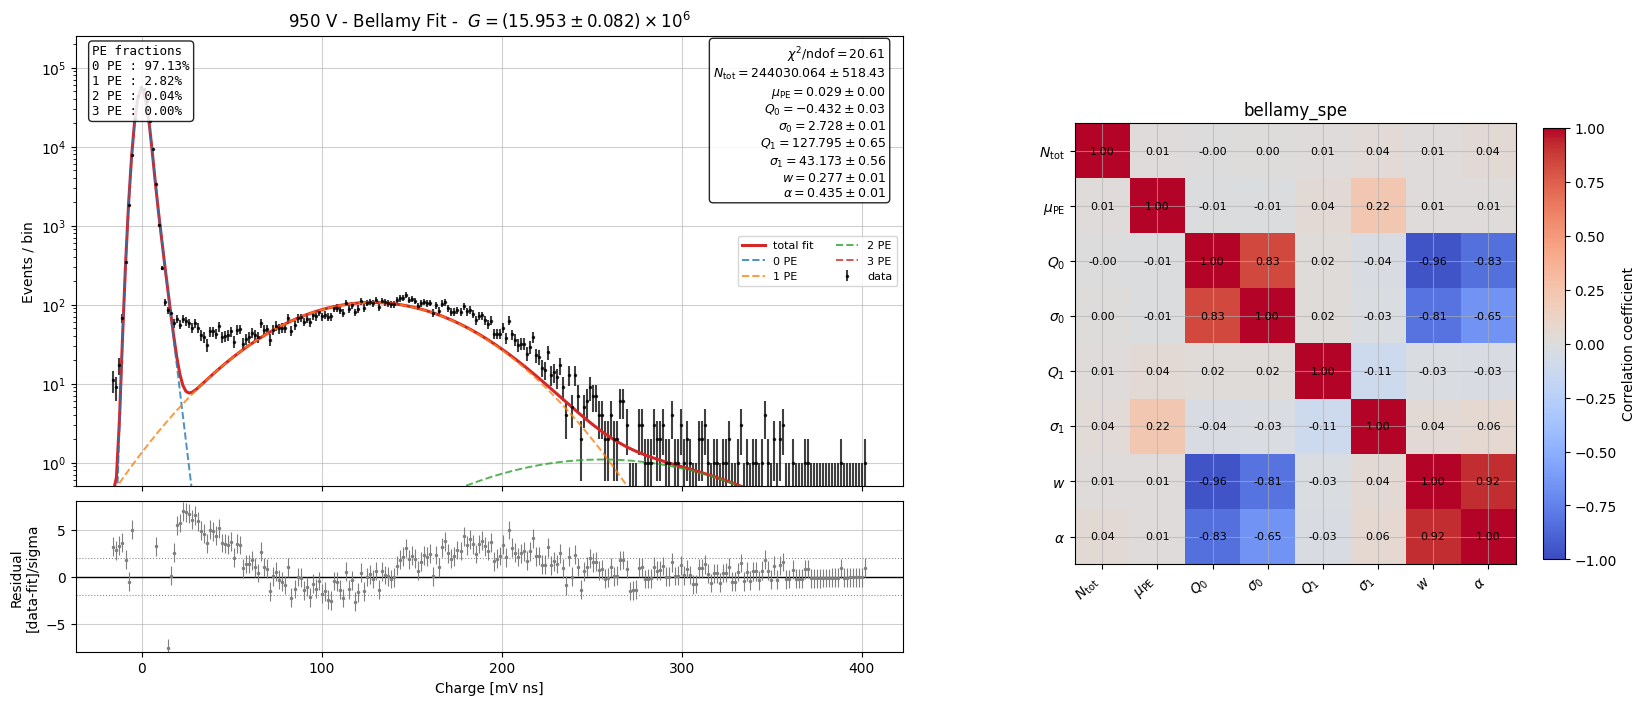

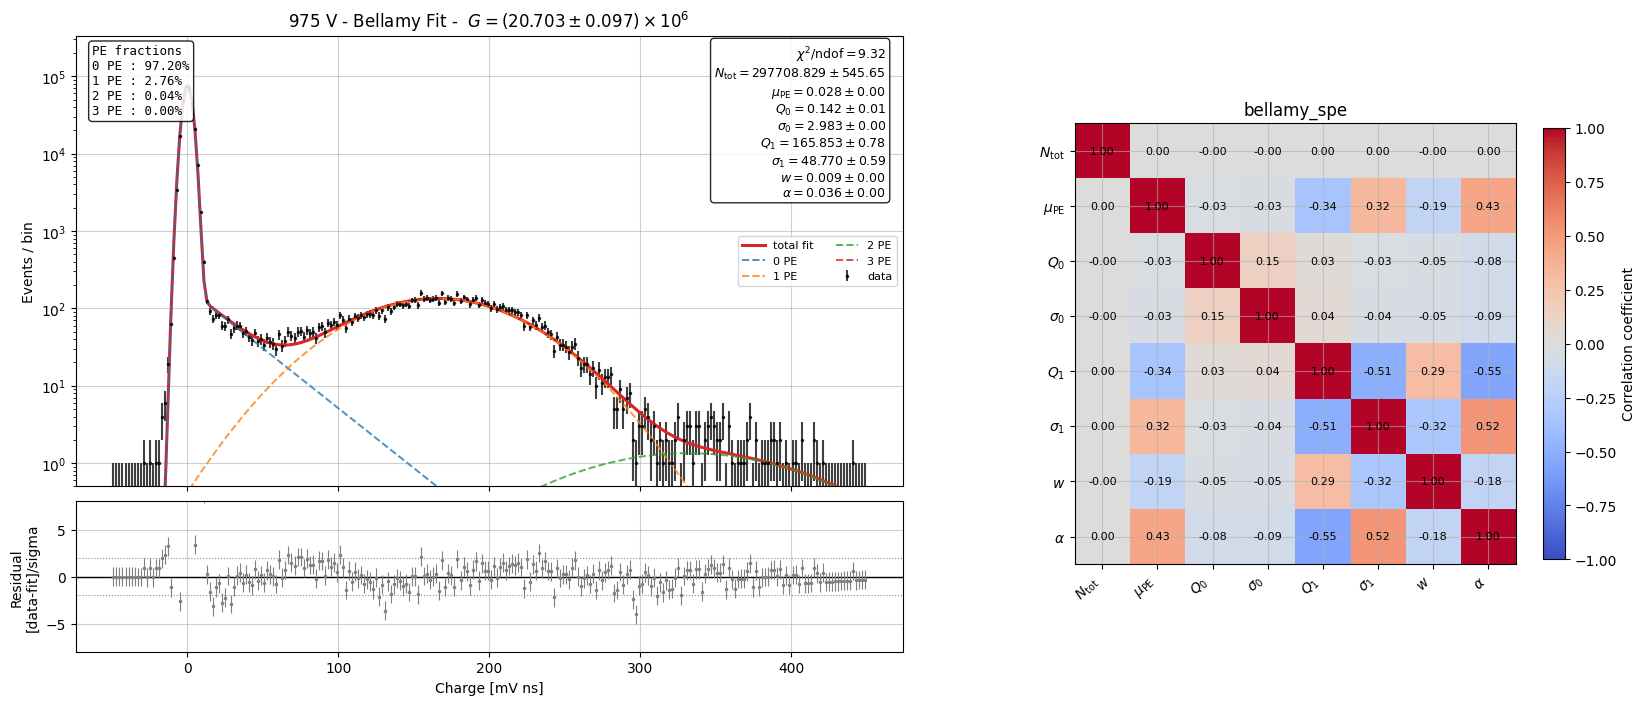

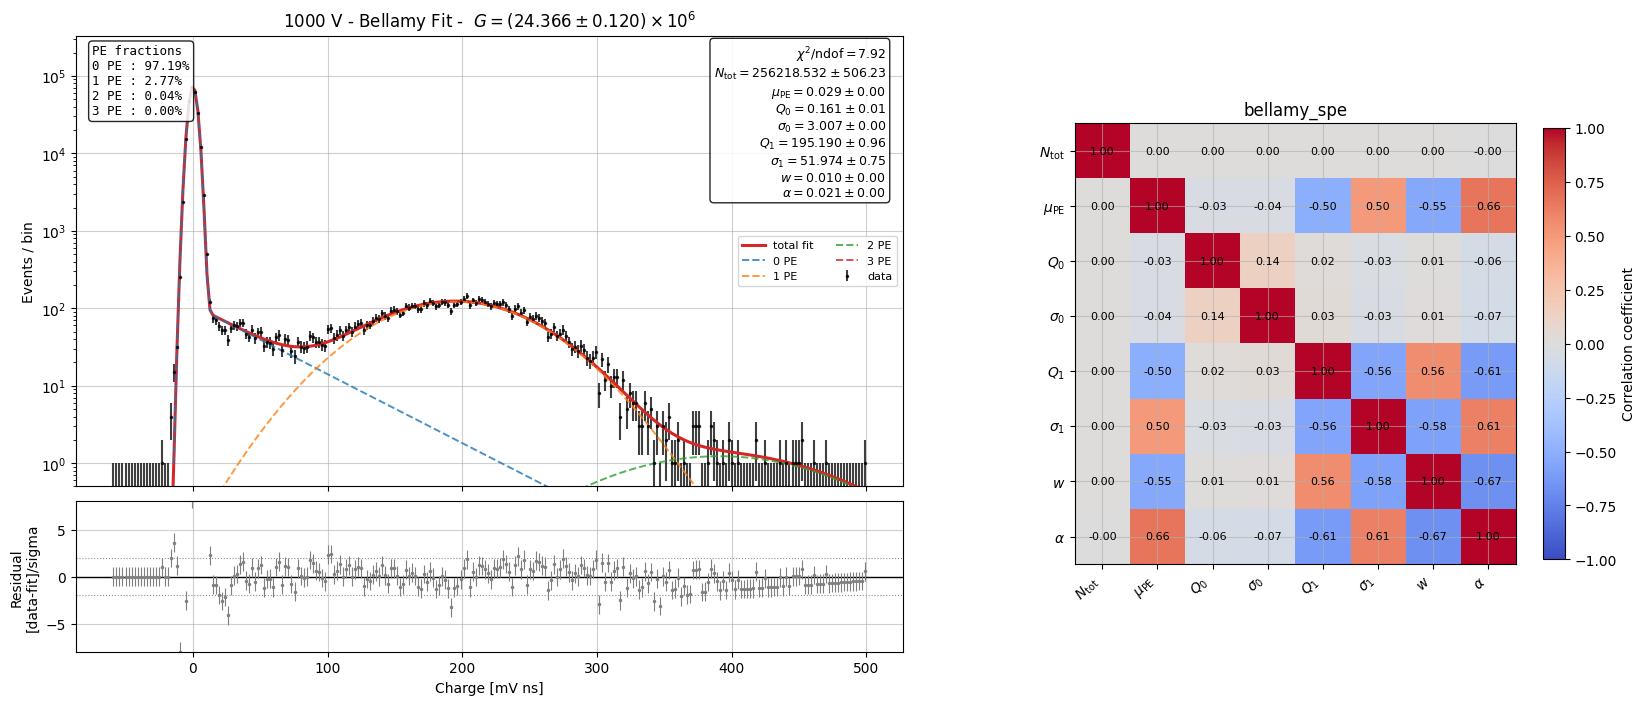

In [21]:
date = "260709"
fit_inputs = f"fit_data/{date}"
save_dir = f'plots/{date}/fit'
with open('config_files/fit_config.yaml') as f:
    cfg = yaml.safe_load(f)

for inputV in np.arange(750, 1001, 25):
# for inputV in np.arange(975, 1001, 25):
    file_name = f"WA0089_{inputV}V_20MHz_led100" 
    fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults", save_results=True)

# Bellamy Scan

In [19]:
# date = "260709"
# fit_inputs = f"fit_data/{date}"
# save_dir = f'plots/{date}/fit_test'
# with open('config_files/fit_config.yaml') as f:
#     cfg = yaml.safe_load(f)

# # for inputV in np.arange(750, 1001, 25):
# inputV = 750
# file_name = f"WA0089_{inputV}V_20MHz_led100" 

# # initPars = get_initPars( cfg, file_name, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults")

# for w_mean in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
#     initPars = {
#         'q0_mV_ns':     [ 0.3,  -5.0,   5.0, False],
#         'sigma0_mV_ns': [ 3.9, '1e-4', 10.0, False],
#         'q1_mV_ns':     [29.0,  5.0,  200.0, False],
#         'sigma1_mV_ns': [12.0,  1.0,   80.0, False],
#         'mu_pe':        [ 0.06, 0.001,  5.0, False],
#         'w':            [ w_mean,  0.0,    1.0, True],
#         'alpha':        [ 0.3,  0.0,   10.0, False]
#     }
#     # print(int(w_mean*10))
#     fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults", lbl=f'w{int(w_mean*10)}_fixed', save_results=True, initPars=initPars)


In [20]:
# 